# Ground-Truth Validation: Linear vs Nonlinear Causal Systems

This notebook validates the toolkit against simulated systems with known causal
direction — one linear (for Granger) and one nonlinear (for CCM/TE) — to confirm
correctness before applying the toolkit to real market data.

See `02_spx_vix_volatility_feedback.ipynb` for the main real-data finding.

## Why causality, not just correlation?

Two things can move together (correlate) without either one causing the other —
for example, ice cream sales and drowning deaths both rise in summer, but ice
cream doesn't cause drowning; heat causes both. In finance and many other fields,
knowing the *direction* of influence matters far more than just knowing two
things are related.

This notebook tests our toolkit on data where we control the "ground truth" --
we build the data ourselves, so we already know exactly which variable causes
which. This lets us check: does each method (Granger, Transfer Entropy, CCM)
correctly recover the direction we built in? And where does each method get
fooled?

In [1]:
from pathlib import Path
import sys
import contextlib
import io

project_root = Path.cwd().resolve()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

with contextlib.redirect_stdout(io.StringIO()):
    import dtw  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import PreprocessingConfig, AnalysisConfig, download_yfinance_series, run_analysis_pipeline

pd.set_option("display.float_format", lambda v: f"{v:.6f}")

### What "X causes Y" means in this simulated system

We're generating two fake time series, X and Y, using a simple rule:
Y's next value partly depends on X's *previous* value, plus some of Y's own past,
plus random noise. X, on the other hand, only depends on its own past -- Y has
no effect on X at all. So by construction, X causes Y, and Y does NOT cause X.
This gives us a known correct answer to check each method against.

### A quick note on reading the output below

Each pipeline run below prints, in order: an ADF stationarity check, a Granger
causality table by lag, a TE/CCM parameter sweep, and then surrogate
significance tests. If you just want the verdict, skip to the bolded summary
lines and the surrogate p-values.

A surrogate test works like this: we randomly shuffle (or bootstrap) one
series to destroy any real temporal link between it and the other, then
recompute the causality score many times on this "fake" data to build a null
distribution. The p-value tells us how likely it is that the real, unshuffled
score could have arisen from pure chance. A low p-value (conventionally <0.05)
means the detected causal signal is unlikely to be noise — this is what turns
a raw Granger F-stat, TE, or CCM score into a trustworthy claim rather than a
number that might just reflect randomness or a lucky parameter choice.

## System 1: Linear VAR (X causes Y)

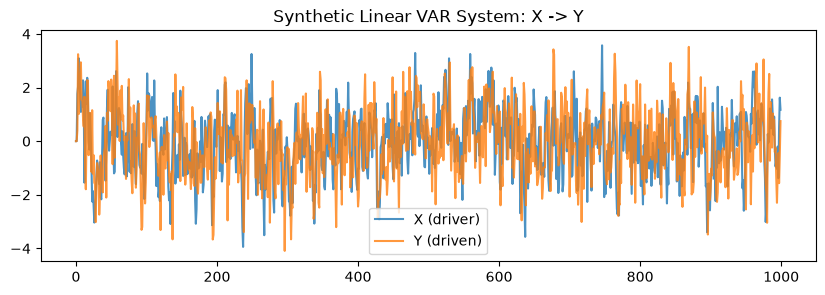

In [2]:
np.random.seed(0)
n = 1000

x_lin = np.zeros(n)
y_lin = np.zeros(n)
for t in range(2, n):
    x_lin[t] = 0.6 * x_lin[t-1] + np.random.normal(scale=1.0)
    y_lin[t] = 0.5 * x_lin[t-1] + 0.3 * y_lin[t-1] + np.random.normal(scale=1.0)

series_x_lin = pd.Series(x_lin, name="X_linear_driver")
series_y_lin = pd.Series(y_lin, name="Y_linear_driven")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(series_x_lin, label="X (driver)", alpha=0.8)
ax.plot(series_y_lin, label="Y (driven)", alpha=0.8)
ax.set_title("Synthetic Linear VAR System: X -> Y")
ax.legend()
plt.show()

In [3]:
linear_config = AnalysisConfig(
    run_lagged_cross_correlation=False,
    run_dtw=False,
    run_granger=True,
    granger_maxlag=5,
    run_granger_surrogates=True,
    run_te=True,
    te_max_lag=3,
    te_max_embed_dim=3,
    run_te_surrogates=True,
    run_ccm=True,
    ccm_max_lag=3,
    ccm_max_embed_dim=3,
    run_ccm_convergence=False,
    run_ccm_surrogates=True,
    n_surrogates=200,
    surrogate_seed=0,
)

linear_results = run_analysis_pipeline(
    series_x_lin, series_y_lin,
    "X_linear_driver", "Y_linear_driven",
    preprocessing_config=PreprocessingConfig(base_representation="raw", standardize=True),
    analysis_config=linear_config,
)

Downstream analyses will use X_linear_driver and Y_linear_driven.
Doing ADF test...

--------------------------------------------------------------------------------
ADF / unit-root test summary for X_linear_driver (diff order 0)
--------------------------------------------------------------------------------
Observations:         999
ADF statistic:        -16.305554
p-value:              0.000000
Used lags:            0
Critical values:      {'1%': -3.4369127451400474, '5%': -2.864437475834273, '10%': -2.568312754566378}
Conclusion:           Stationary (reject unit-root null at alpha=0.05)
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
ADF / unit-root test summary for Y_linear_driven (diff order 0)
--------------------------------------------------------------------------------
Observations:         999
ADF statistic:        -19.043153
p-value:              0.000000
Use

**Interpretation: Granger correctly recovers the linear direction; TE/CCM do not.**

Granger identifies X → Y decisively (F = 357.5 at lag 1 vs F = 1.6 for Y → X),
matching the ground truth, and the surrogate test confirms this is significant
(p = 0.005) while the reverse direction is not (p = 0.39). TE and CCM, however
— both designed to capture nonlinear dependence — actually favor the *wrong*
direction in their best-parameter search here (Y → X slightly outscores X → Y
for both metrics), and neither result clears surrogate significance in the
correct direction.

This illustrates an important limitation: nonlinear-information methods have
no particular advantage on a purely linear, Gaussian-noise system, and can
even be misleading when the true mechanism is linear. Granger — or a
simple lagged correlation test — remains the right tool when there's no reason
to suspect nonlinear coupling.

## System 2: Nonlinear Coupled Logistic Maps (X causes Y)

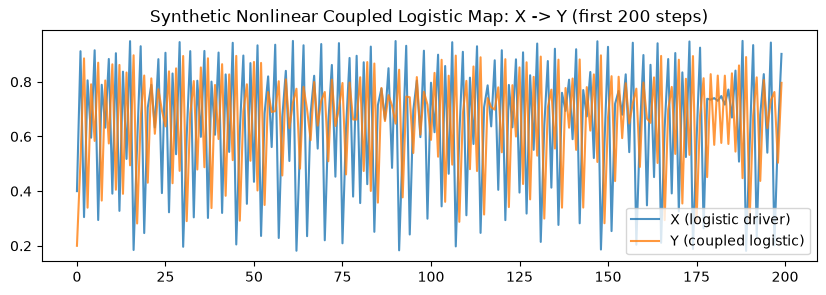

In [4]:
np.random.seed(0)
n = 2000
x_nl = np.zeros(n)
y_nl = np.zeros(n)
x_nl[0], y_nl[0] = 0.4, 0.2
coupling = 0.3

for t in range(1, n):
    x_nl[t] = 3.8 * x_nl[t-1] * (1 - x_nl[t-1])
    y_nl[t] = (1 - coupling) * 3.5 * y_nl[t-1] * (1 - y_nl[t-1]) + coupling * x_nl[t-1]

series_x_nl = pd.Series(x_nl, name="X_nonlinear_driver")
series_y_nl = pd.Series(y_nl, name="Y_nonlinear_driven")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(series_x_nl[:200], label="X (logistic driver)", alpha=0.8)
ax.plot(series_y_nl[:200], label="Y (coupled logistic)", alpha=0.8)
ax.set_title("Synthetic Nonlinear Coupled Logistic Map: X -> Y (first 200 steps)")
ax.legend()
plt.show()

In [5]:
nonlinear_config = AnalysisConfig(
    run_lagged_cross_correlation=False,
    run_dtw=False,
    run_granger=True,
    granger_maxlag=5,
    run_granger_surrogates=True,
    run_te=True,
    te_max_lag=3,
    te_max_embed_dim=3,
    run_te_surrogates=True,
    run_ccm=True,
    ccm_max_lag=3,
    ccm_max_embed_dim=3,
    run_ccm_convergence=False,
    run_ccm_surrogates=True,
    n_surrogates=200,
    surrogate_seed=0,
)

nonlinear_results = run_analysis_pipeline(
    series_x_nl, series_y_nl,
    "X_nonlinear_driver", "Y_nonlinear_driven",
    preprocessing_config=PreprocessingConfig(base_representation="raw", standardize=True),
    analysis_config=nonlinear_config,
)

Downstream analyses will use X_nonlinear_driver and Y_nonlinear_driven.
Doing ADF test...

--------------------------------------------------------------------------------
ADF / unit-root test summary for X_nonlinear_driver (diff order 0)
--------------------------------------------------------------------------------
Observations:         1985
ADF statistic:        -12.120561
p-value:              0.000000
Used lags:            14
Critical values:      {'1%': -3.433648628001351, '5%': -2.8629971502062155, '10%': -2.5675457254979093}
Conclusion:           Stationary (reject unit-root null at alpha=0.05)
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
ADF / unit-root test summary for Y_nonlinear_driven (diff order 0)
--------------------------------------------------------------------------------
Observations:         1986
ADF statistic:        -11.720591
p-value:          

### Robustness check: does weaker coupling reduce CCM symmetry?

At coupling=0.3, CCM found near-symmetric scores in both directions (0.998 vs 0.955),
likely due to strong synchronization between the two systems. Reducing coupling to 0.1
should weaken this synchronization and produce a more clearly asymmetric CCM result
favoring X -> Y, which is the theoretically expected signature of true one-way coupling.

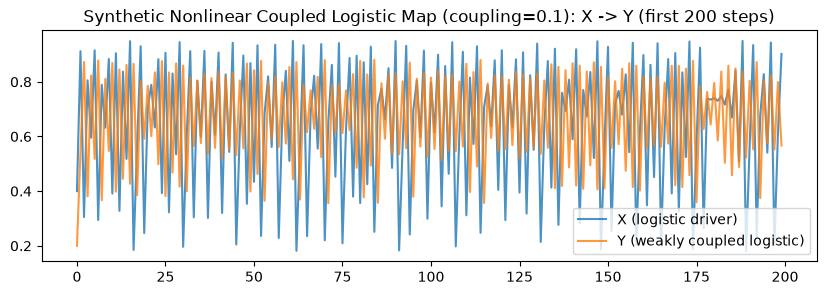

Downstream analyses will use X_nonlinear_driver_weak and Y_nonlinear_driven_weak.
Doing ADF test...

--------------------------------------------------------------------------------
ADF / unit-root test summary for X_nonlinear_driver_weak (diff order 0)
--------------------------------------------------------------------------------
Observations:         1985
ADF statistic:        -12.120561
p-value:              0.000000
Used lags:            14
Critical values:      {'1%': -3.433648628001351, '5%': -2.8629971502062155, '10%': -2.5675457254979093}
Conclusion:           Stationary (reject unit-root null at alpha=0.05)
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
ADF / unit-root test summary for Y_nonlinear_driven_weak (diff order 0)
--------------------------------------------------------------------------------
Observations:         1980
ADF statistic:        -11.57670

In [6]:
np.random.seed(0)
n = 2000
coupling_weak = 0.1

x_nl_weak = np.zeros(n)
y_nl_weak = np.zeros(n)
x_nl_weak[0], y_nl_weak[0] = 0.4, 0.2

for t in range(1, n):
    x_nl_weak[t] = 3.8 * x_nl_weak[t-1] * (1 - x_nl_weak[t-1])
    y_nl_weak[t] = (1 - coupling_weak) * 3.5 * y_nl_weak[t-1] * (1 - y_nl_weak[t-1]) + coupling_weak * x_nl_weak[t-1]

series_x_nl_weak = pd.Series(x_nl_weak, name="X_nonlinear_driver_weak")
series_y_nl_weak = pd.Series(y_nl_weak, name="Y_nonlinear_driven_weak")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(series_x_nl_weak[:200], label="X (logistic driver)", alpha=0.8)
ax.plot(series_y_nl_weak[:200], label="Y (weakly coupled logistic)", alpha=0.8)
ax.set_title(f"Synthetic Nonlinear Coupled Logistic Map (coupling={coupling_weak}): X -> Y (first 200 steps)")
ax.legend()
plt.show()

nonlinear_weak_config = AnalysisConfig(
    run_lagged_cross_correlation=False,
    run_dtw=False,
    run_granger=True,
    granger_maxlag=5,
    run_granger_surrogates=True,
    run_te=True,
    te_max_lag=3,
    te_max_embed_dim=3,
    run_te_surrogates=True,
    run_ccm=True,
    ccm_max_lag=3,
    ccm_max_embed_dim=3,
    run_ccm_convergence=False,
    run_ccm_surrogates=True,
    n_surrogates=50,
    surrogate_seed=0,
    surrogate_method="both",
)

nonlinear_weak_results = run_analysis_pipeline(
    series_x_nl_weak, series_y_nl_weak,
    "X_nonlinear_driver_weak", "Y_nonlinear_driven_weak",
    preprocessing_config=PreprocessingConfig(base_representation="raw", standardize=True),
    analysis_config=nonlinear_weak_config,
)

### Interpretation: coupling strength drives CCM symmetry artifacts

Reducing coupling from 0.3 to 0.1 caused CCM's reverse-direction score to collapse from
0.955 to 0.058 (surrogate p=0.078, no longer significant), while the correct X -> Y
direction remained strongly significant (0.988, p=0.02). This confirms that CCM's
near-symmetric result at high coupling was driven by attractor synchronization between
the two systems, not a genuine bidirectional causal link -- a known limitation of CCM
noted in the original Sugihara et al. (2012) framework. Granger's spurious Y -> X
signal also weakened substantially (F=129.7 -> F=4.2), showing that nonlinear
misspecification effects in Granger are themselves sensitive to coupling strength.

### What to look for

- Granger correctly ranks X → Y as the stronger direction as expected, since it's
  still sensitive to some linear component of the coupling, but it also produces a
  spuriously significant Y → X result even though Y has zero true causal effect on X
  by construction. This is a known failure mode: linear F-tests can be misled by
  nonlinear dynamics into over-detecting causality in the wrong direction, not just
  under-detecting it in the right one.
- CCM and TE correctly identify X → Y as dominant, and the CCM robustness check above
  (varying coupling strength) shows that Granger's spurious Y → X signal and CCM's
  near-symmetric scores both shrink substantially as coupling weakens — confirming
  these are synchronization/misspecification artifacts rather than genuine bidirectional
  causality.

## Takeaway

Across both systems, no single method is universally reliable: Granger wins on
the linear system but produces a false positive in the wrong direction on the
nonlinear system, while CCM/TE correctly find the true direction on the
nonlinear system but generate misleading, near-symmetric scores when the
coupled systems synchronize at high coupling strength. Surrogate testing is
essential in both cases — it is what actually distinguishes a trustworthy
causal signal from noise or a synchronization artifact.

With this ground-truth check confirming the toolkit behaves as theory
predicts, the next notebook applies it to real SPX/VIX data. See
`02_spx_vix_volatility_feedback.ipynb` for that analysis.